# 🚕 NYC Taxi Trip Duration — Full Analysis & Prediction Pipeline

> **Goal:** Predict how long a New York City taxi trip will take (in seconds),
> starting from raw GPS coordinates and timestamps.

---

## 📋 Table of Contents

| # | Section |
|---|---------|
| 1 | 📦 Setup & Imports & Load Data |
| 2 | 🔍 Data Overview |
| 3 | 🧹 Data Cleaning |
| 4 | 🛠️ Feature Engineering |
| 5 | 📊 Exploratory Data Analysis (EDA) |
| 6 | 🔗 Correlation Analysis |
| 7 | 🤖 Modeling Pipeline |
| 8 | 📈 Evaluation |

---

> 💡 **Key Rule:** Any feature that uses the **target variable** (`trip_duration`)
> during its computation is **DATA LEAKAGE** and will be marked with ✖️.
> Only ✅ features are used in modeling.

## 1. Setup & Imports & Load Data

In [29]:
# ── Standard libraries ─────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")   # keep output clean

# ── Data manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# ── Styling defaults ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ── continue in the modeling section ────────────────────────────────────────

# ── List available input files ──────────────────────────────────────────────
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nyc-taxi-trip-duration/train.zip
/kaggle/input/nyc-taxi-trip-duration/test.zip
/kaggle/input/nyc-taxi-trip-duration/sample_submission.zip


In [30]:
df = pd.read_csv('/kaggle/input/nyc-taxi-trip-duration/train.zip')

print('shape:', df.shape)
df.head()

shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## 2. Data Overview

Before touching anything, we inspect the raw data to understand:
- **Shape** — how many rows and columns?
- **Data types** — are dates parsed correctly?
- **Missing values** — any nulls?
- **Duplicates** — are IDs unique?

In [31]:
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "nulls"   : df.isnull().sum(),
  # "null_%"  : (df.isnull().mean() * 100).round(2),
    "nunique" : df.nunique(),
})
print(info.to_string())

                      dtype  nulls  nunique
id                   object      0  1458644
vendor_id             int64      0        2
pickup_datetime      object      0  1380222
dropoff_datetime     object      0  1380377
passenger_count       int64      0       10
pickup_longitude    float64      0    23047
pickup_latitude     float64      0    45245
dropoff_longitude   float64      0    33821
dropoff_latitude    float64      0    62519
store_and_fwd_flag   object      0        2
trip_duration         int64      0     7417


In [32]:
df['id'].duplicated().sum()

np.int64(0)

In [33]:
df.drop(columns=['id'], inplace=True)

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df.dtypes

vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime              object
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

## 3. Data Cleaning

We remove rows that are **physically impossible or clearly erroneous**:

| Check | Reason |
|-------|--------|
| `trip_duration ≤ 0` | A trip can't take zero or negative time |
| `trip_duration > 10 800 s` | 3 hours+ in a NYC taxi is unrealistic |
| `trip_duration < 10 s` | Less than 10 seconds — almost certainly a sensor error |
| Coordinates outside NYC bounding box | GPS noise / bad data |

> 📌 We **do NOT use IQR** for trip duration because the distribution is
> heavily right-skewed — IQR would discard many valid long trips.
> Domain-knowledge thresholds are more reliable here.

In [34]:
# I found some problems:

display(df[df['pickup_latitude']< 40.50].head(2)) # the following column is not in New York
display(df[df['trip_duration']==1].head(2)) # and duration time like this is not reliable
display(df[df['passenger_count']==0].head(2)) # are they little ghosts or what?! 😄
# so look at what we're going to do

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
47554,2,2016-01-09 14:58:08,2016-01-09 15:13:20,1,-74.079620,40.449749,-74.062263,40.444698,N,912
73032,2,2016-01-16 10:03:02,2016-01-16 10:12:44,1,-74.069733,40.433842,-74.082153,40.441662,N,582


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
35196,1,2016-04-17 11:44:49,2016-04-17 11:44:50,1,-73.940384,40.786423,-73.940300,40.786373,N,1
207497,1,2016-05-17 09:03:38,2016-05-17 09:03:39,1,-73.819893,40.740822,-73.819885,40.740822,N,1


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
62744,2,2016-06-06 16:39:09,2016-06-07 16:30:50,0,-73.776367,40.645248,-73.776360,40.645260,N,85901
136519,2,2016-01-01 05:01:32,2016-01-01 05:01:36,0,-73.993134,40.757473,-73.993294,40.757538,N,4


In [35]:
def clean_data(X: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans raw taxi trip data before feature engineering.

    This function removes unrealistic or corrupted rows based on:
      1. Trip duration bounds
      2. Geographic bounding box for NYC
      3. Valid passenger count

    It ensures the model trains only on plausible trips,
    reducing noise and improving stability.
    """

    # Define acceptable trip duration range in seconds
    # Very short trips are likely sensor glitches
    # Very long trips are usually data errors
    MIN_DURATION   =    10
    MAX_DURATION   = 10_800

    # Approximate geographic bounding box for New York City
    # Used to remove outliers far outside the service area
    LAT_MIN, LAT_MAX =  40.50,  40.93
    LON_MIN, LON_MAX = -74.25, -73.65
    
    # Keep trips within valid duration range
    mask_duration = X['trip_duration'].between(MIN_DURATION, MAX_DURATION)

    # Keep pickup locations inside NYC bounding box
    mask_pickup = (
        X['pickup_latitude'].between(LAT_MIN, LAT_MAX) &
        X['pickup_longitude'].between(LON_MIN, LON_MAX)
    )

    # Keep dropoff locations inside NYC bounding box
    mask_dropoff = (
        X['dropoff_latitude'].between(LAT_MIN, LAT_MAX) &
        X['dropoff_longitude'].between(LON_MIN, LON_MAX)
    )

    # Remove trips with zero or negative passengers
    mask_passenger = X['passenger_count'] > 0

    # Apply all filters together
    # Only rows satisfying all conditions are kept
    X = X[mask_duration & mask_pickup & mask_dropoff & mask_passenger].copy()

    # Reset index after row removal to keep dataset clean
    X.reset_index(drop=True, inplace=True)

    return X

rows_before = len(df)
print(f"Rows before cleaning : {rows_before:,}")
df = clean_data(df)
print(f"Rows after  cleaning : {len(df):,}")
print(f"Removed              : {rows_before - len(df):,} rows")

Rows before cleaning : 1,458,644
Rows after  cleaning : 1,453,522
Removed              : 5,122 rows


## 4. Feature Engineering

We create **new informative features** from the raw columns.

### 🗺️ Spatial Features
| Feature | Description | Modeling? |
|---------|-------------|-----------|
| `distance_km` | Haversine distance between pickup & dropoff | ✅ Safe |
| `bearing` | Compass direction from pickup to dropoff | ✅ Safe |

### 🕐 Temporal Features
| Feature | Description | Modeling? |
|---------|-------------|-----------|
| `hour` | Hour of pickup (0–23) | ✅ Safe |
| `dayofweek` | Day of week (0=Mon … 6=Sun) | ✅ Safe |
| `month` | Month of year (1–12) | ✅ Safe |
| `is_weekend` | 1 if Saturday or Sunday | ✅ Safe |
| `hour_sin/cos` | Cyclical hour encoding | ✅ Safe |
| `day_sin/cos` | Cyclical day-of-week encoding | ✅ Safe |

### ✖️ Leakage Feature (EDA only)
| Feature | Why Leaky |
|---------|-----------|
| `speed` | Computed as `distance / duration` — uses the target! |

> 💡 **Cyclical encoding** converts time into sin/cos pairs so the model
> understands that hour 23 and hour 0 are *adjacent*, not far apart.


In [36]:
EARTH_RADIUS_KM = 6_371.0  # mean radius of Earth

def calculate_distance(lon1, lat1, lon2, lat2):
    """
    Haversine formula — great-circle distance between two points on Earth.
    Returns distance in kilometres.
    """
    # Convert decimal degrees → radians
    phi1, phi2       = np.radians(lat1), np.radians(lat2)
    d_phi            = np.radians(lat2 - lat1)
    d_lambda         = np.radians(lon2 - lon1)

    # Core formula
    a = (np.sin(d_phi   / 2) ** 2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return EARTH_RADIUS_KM * c   # kilometres


def calculate_bearing(lon1, lat1, lon2, lat2):
    """
    Forward azimuth (bearing) from point 1 → point 2.
    Returns angle in degrees (−180 to +180).
    Useful as a proxy for traffic corridor direction.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    d_lon = lon2 - lon1
    y     = np.sin(d_lon) * np.cos(lat2)
    x     = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(d_lon)
    return np.degrees(np.arctan2(y, x))


# ── Apply spatial features ──────────────────────────────────────────────────
df['distance_km'] = calculate_distance(
    df['pickup_longitude'],  df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

df['bearing'] = calculate_bearing(
    df['pickup_longitude'],  df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

In [37]:
# ── Temporal features ────────────────────────────────────────────────────────
dt = df['pickup_datetime'].dt

df['hour']       = dt.hour
df['dayofweek']  = dt.dayofweek          # 0 = Monday, 6 = Sunday
df['month']      = dt.month
df['day_of_week_name'] = dt.day_name()   # human-readable label for plots
df['is_weekend'] = (dt.dayofweek >= 5).astype(int)

# ── Cyclical encoding ────────────────────────────────────────────────────────
# Why? Hour 23 and hour 0 are close — but to a linear model they look far apart.
# sin/cos encoding wraps the circle so adjacency is preserved.
df['hour_sin'] = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']  = np.sin(2 * np.pi * df['dayofweek'] /  7)
df['day_cos']  = np.cos(2 * np.pi * df['dayofweek'] /  7)

# ── ✖️ Speed — EDA only, DO NOT use in modeling (uses target variable) ───────
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

# ── Drop the datetime column now that we extracted everything ────────────────
df.drop(columns=['pickup_datetime'], inplace=True)

print("All features engineered successfully")
print(f"Final shape: {df.shape}")
df.head()

All features engineered successfully
Final shape: (1453522, 21)


,vendor_id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,...,hour,dayofweek,month,day_of_week_name,is_weekend,hour_sin,hour_cos,day_sin,day_cos,speed_kmh
0,2,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,...,17,0,3,Monday,0,-0.965926,-0.258819,0.000000,1.000000,11.856428
1,1,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,...,0,6,6,Sunday,1,0.000000,1.000000,-0.781831,0.623490,9.803659
2,2,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,...,11,1,1,Tuesday,0,0.258819,-0.965926,0.781831,0.623490,10.822201
3,2,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,...,19,2,4,Wednesday,0,-0.965926,0.258819,0.974928,-0.222521,12.465721
4,2,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,...,13,5,3,Saturday,1,-0.258819,-0.965926,-0.974928,-0.222521,9.836594


## 📊 5. Exploratory Data Analysis

> **EDA goal:** *Understand* the data — not to train anything.
> We look at distributions, relationships, outliers, and patterns.
>
> ⚠️ Note: `speed_kmh` is included here for insight only.
> It will **not** be used in the model (data leakage).

### 📐 5.1 — Basic Statistics


In [38]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','50%','std'])

,count,mean,std,min,25%,50%,75%,max
vendor_id,1453522.000000,1.534586,0.498803,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,1453522.000000,1.664691,1.314177,1.000000,1.000000,1.000000,2.000000,9.000000
pickup_longitude,1453522.000000,-73.973552,0.037915,-74.233780,-73.991867,-73.981750,-73.967392,-73.652458
pickup_latitude,1453522.000000,40.750975,0.027941,40.506294,40.737389,40.754120,40.768360,40.927170
dropoff_longitude,1453522.000000,-73.973514,0.035005,-74.248909,-73.991325,-73.979767,-73.963081,-73.650009
dropoff_latitude,1453522.000000,40.751786,0.031959,40.508598,40.735920,40.754532,40.769798,40.929810
trip_duration,1453522.000000,836.986337,656.172686,10.000000,398.000000,662.000000,1073.000000,10731.000000
distance_km,1453522.000000,3.424947,3.875685,0.000000,1.234625,2.095548,3.874101,45.109645
bearing,1453522.000000,-15.720452,104.530253,-179.992701,-125.427527,8.253495,53.394026,180.000000
hour,1453522.000000,13.608225,6.398056,0.000000,9.000000,14.000000,19.000000,23.000000


### ⏱️ 5.2 — Target Distribution: Trip Duration

The distribution is **right-skewed** — most trips are short,
but a long tail of longer trips exists.
This is why we will use **log-transformation** before modeling.

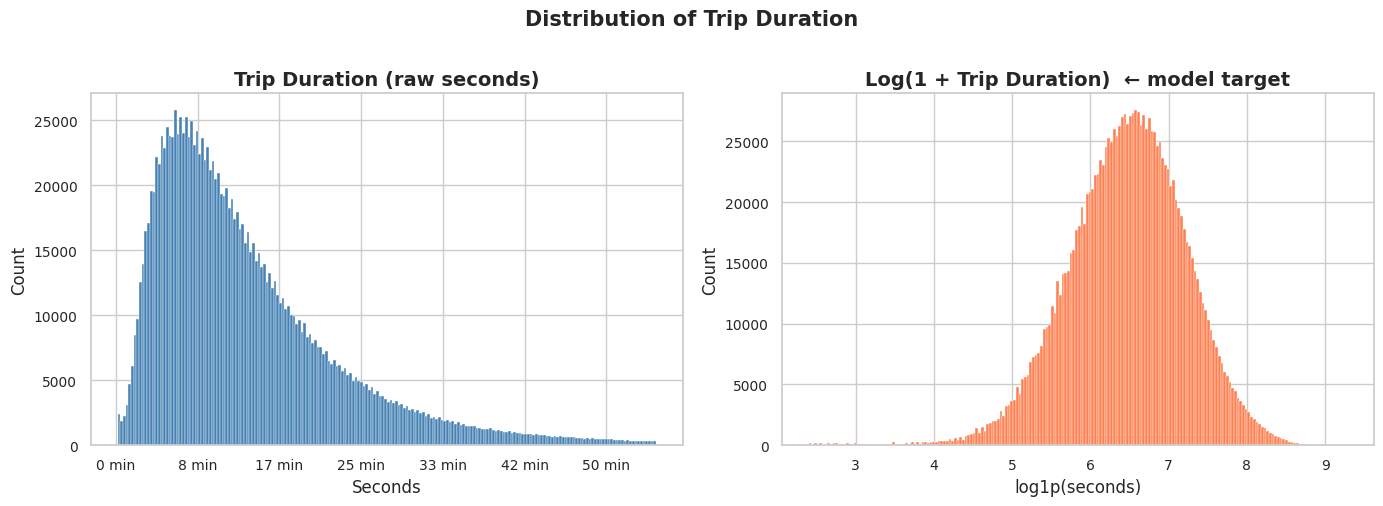

Median trip : 11.0 minutes
Mean trip   : 13.9 minutes
Skewness    : 2.30


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw duration (trimmed at 99th percentile for readability)
cap = df['trip_duration'].quantile(0.99)
axes[0].hist(df.loc[df['trip_duration'] <= cap, 'trip_duration'],
             bins=200, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title("Trip Duration (raw seconds)")
axes[0].set_xlabel("Seconds")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f} min")) # X in minutes instead of seconds

# Log-transformed duration
axes[1].hist(np.log1p(df['trip_duration']),
             bins=200, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title("Log(1 + Trip Duration)  ← model target")
axes[1].set_xlabel("log1p(seconds)")

for ax in axes:
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Trip Duration", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Median trip : {df['trip_duration'].median()/60:.1f} minutes")
print(f"Mean trip   : {df['trip_duration'].mean()/60:.1f} minutes")
print(f"Skewness    : {df['trip_duration'].skew():.2f}")

### 📏 5.3 — Distance Distribution

Distance also has a strong right skew.
The bulk of NYC taxi trips are **under 10 km** — makes sense for a dense city.


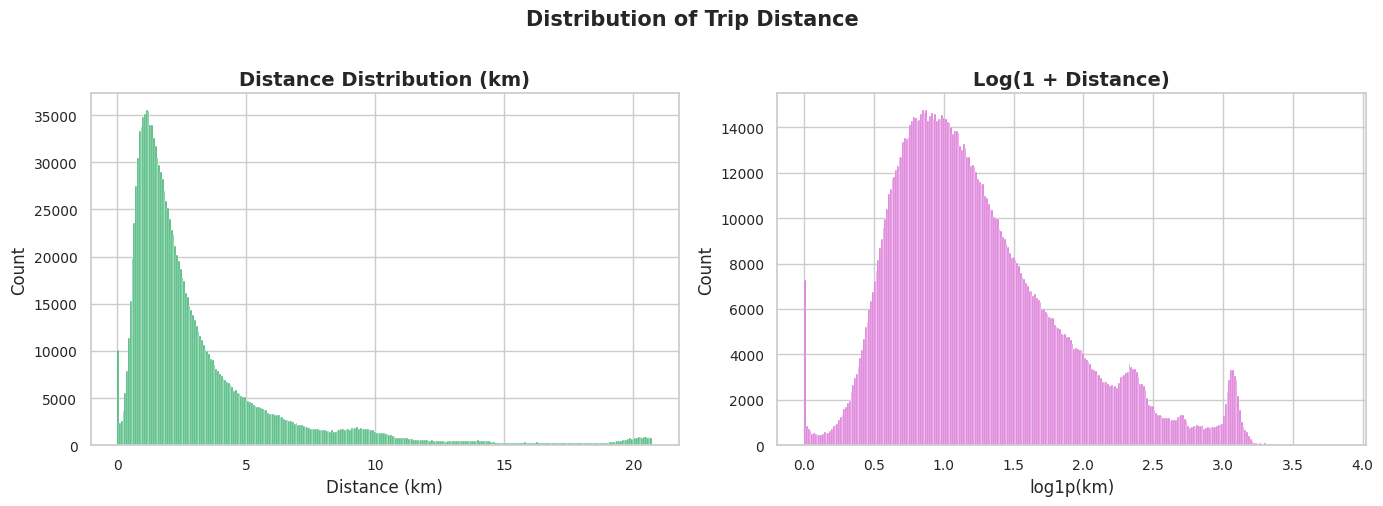

Median distance : 2.10 km
Mean distance   : 3.42 km


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap_dist = df['distance_km'].quantile(0.99)

axes[0].hist(df.loc[df['distance_km'] <= cap_dist, 'distance_km'],
             bins=300, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[0].set_title("Distance Distribution (km)")
axes[0].set_xlabel("Distance (km)")

axes[1].hist(np.log1p(df['distance_km']),
             bins=300, color='orchid', edgecolor='white', linewidth=0.3)
axes[1].set_title("Log(1 + Distance)")
axes[1].set_xlabel("log1p(km)")

for ax in axes:
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Trip Distance", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Median distance : {df['distance_km'].median():.2f} km")
print(f"Mean distance   : {df['distance_km'].mean():.2f} km")

### 🚦 5.4 — Speed Distribution  ✖️ (EDA only — data leakage)

Speed is **derived from the target**, so it **cannot** be used in modeling.
But it helps us validate data quality: real NYC taxi speeds are 5–80 km/h.

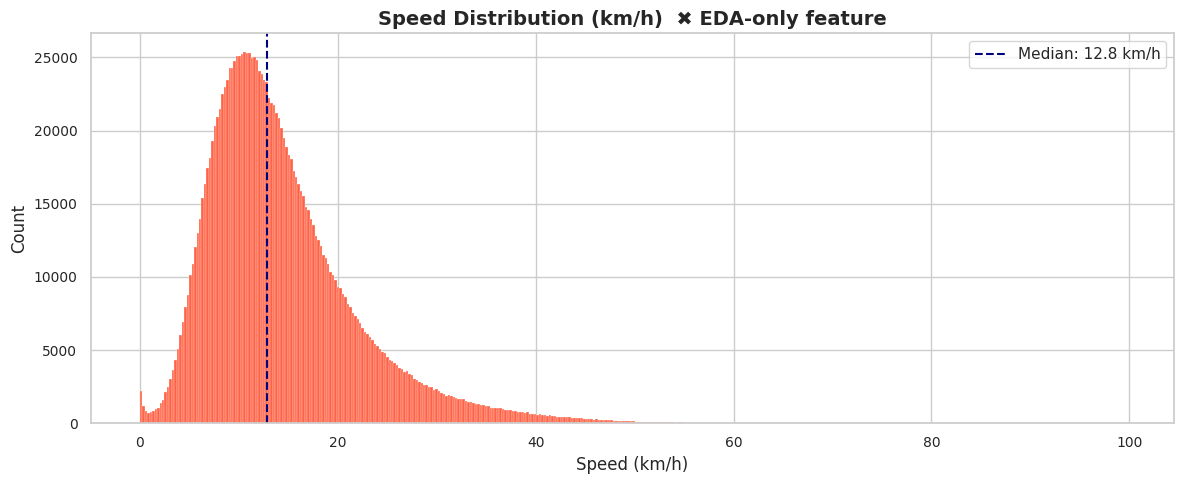

Trips with speed < 1 km/h  : 10,086   ← likely bad GPS
Trips with speed > 80 km/h : 122  ← suspiciously fast


In [41]:
# Filter to realistic speed range for EDA insight
speed_eda = df['speed_kmh'][(df['speed_kmh'] > 0) & (df['speed_kmh'] <= 100)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(speed_eda, bins=400, color='tomato', edgecolor='white', linewidth=0.2)
ax.set_title("Speed Distribution (km/h)  ✖️ EDA-only feature")
ax.set_xlabel("Speed (km/h)")
ax.set_ylabel("Count")
ax.axvline(speed_eda.median(), color='navy', linestyle='--', linewidth=1.5,
           label=f"Median: {speed_eda.median():.1f} km/h")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trips with speed < 1 km/h  : {(df['speed_kmh'] < 1).sum():,}   ← likely bad GPS")
print(f"Trips with speed > 80 km/h : {(df['speed_kmh'] > 80).sum():,}  ← suspiciously fast")

### 🕐 5.5 — Hourly & Weekly Patterns

Rush hours and weekend behavior are the strongest time signals for trip duration.

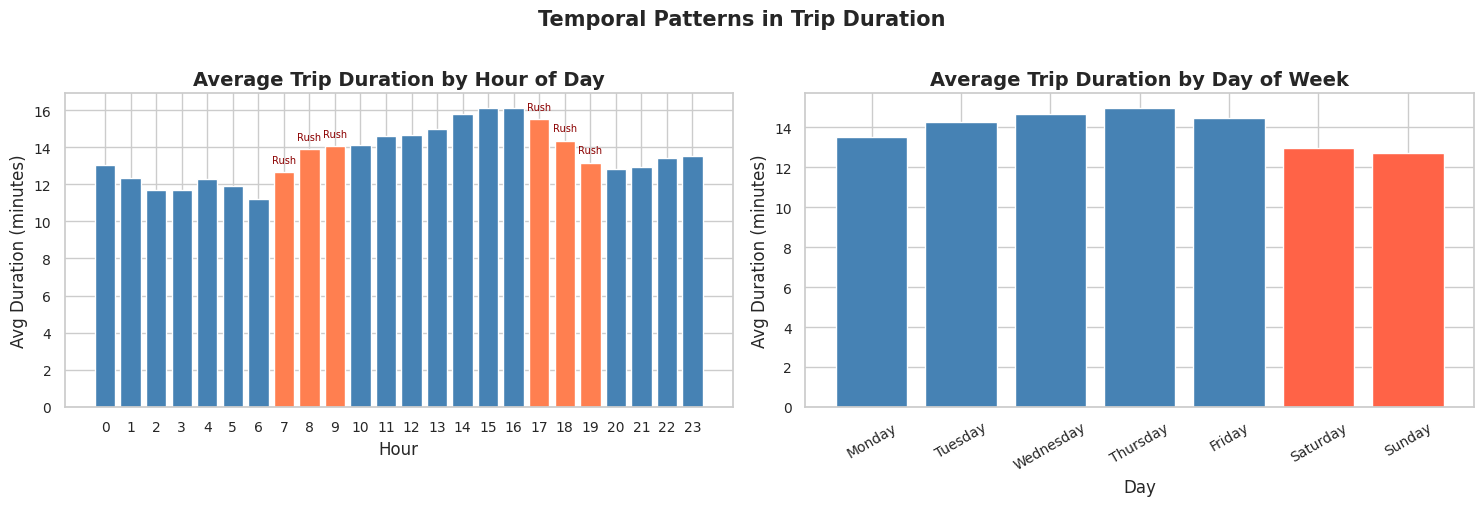

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Trips per hour ───────────────────────────────────────────────────────────
hourly = df.groupby('hour')['trip_duration'].agg(['mean','count'])

color = ['coral' if h in [7,8,9,17,18,19] else 'steelblue' for h in hourly.index]
axes[0].bar(hourly.index, hourly['mean'] / 60, color=color, edgecolor='white')
axes[0].set_title("Average Trip Duration by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Duration (minutes)")
axes[0].set_xticks(range(0, 24))
# Annotate rush hours
for h in [7, 8, 9, 17, 18, 19]:
    axes[0].annotate("Rush", xy=(h, hourly.loc[h,'mean']/60),
                     xytext=(h, hourly.loc[h,'mean']/60 + 0.5),
                     fontsize=7, ha='center', color='darkred')

# ── Trips per day of week ────────────────────────────────────────────────────
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily       = df.groupby('day_of_week_name')['trip_duration'].mean().reindex(day_order) / 60
weekend_col = ['tomato' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order] # weekend

axes[1].bar(daily.index, daily.values, color=weekend_col, edgecolor='white')
axes[1].set_title("Average Trip Duration by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Duration (minutes)")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Temporal Patterns in Trip Duration", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📅 5.6 — Three-Panel Day View: Duration, Distance & Speed

Seeing all three metrics together reveals whether longer trips on certain days
are due to *distance* or *congestion* (slow speed).

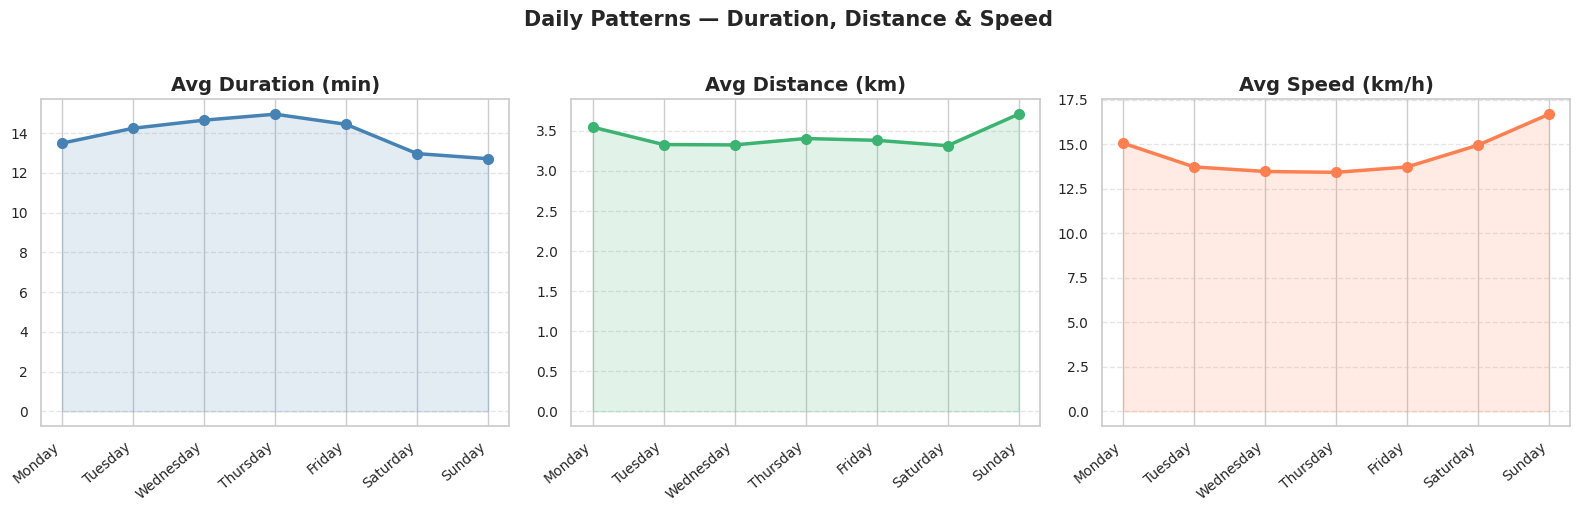

In [43]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
agg = df.groupby('day_of_week_name').agg(
    avg_duration = ('trip_duration', 'mean'),
    avg_distance = ('distance_km',   'mean'),
    avg_speed    = ('speed_kmh',     'mean'),
).reindex(day_order)
agg['avg_duration'] /= 60   # convert to minutes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics  = ['avg_duration', 'avg_distance', 'avg_speed']
titles   = ['Avg Duration (min)', 'Avg Distance (km)', 'Avg Speed (km/h)']
colors   = ['steelblue', 'mediumseagreen', 'coral']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(agg.index, agg[metric], marker='o', linewidth=2.5,
            markersize=7, color=color)
    ax.fill_between(range(7), agg[metric].values, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_order, rotation=40, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Daily Patterns — Duration, Distance & Speed", fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🏢 5.7 — Vendor & Store-and-Forward Flag

Checking whether vendor choice or the store-and-forward flag has any
relationship with trip duration.

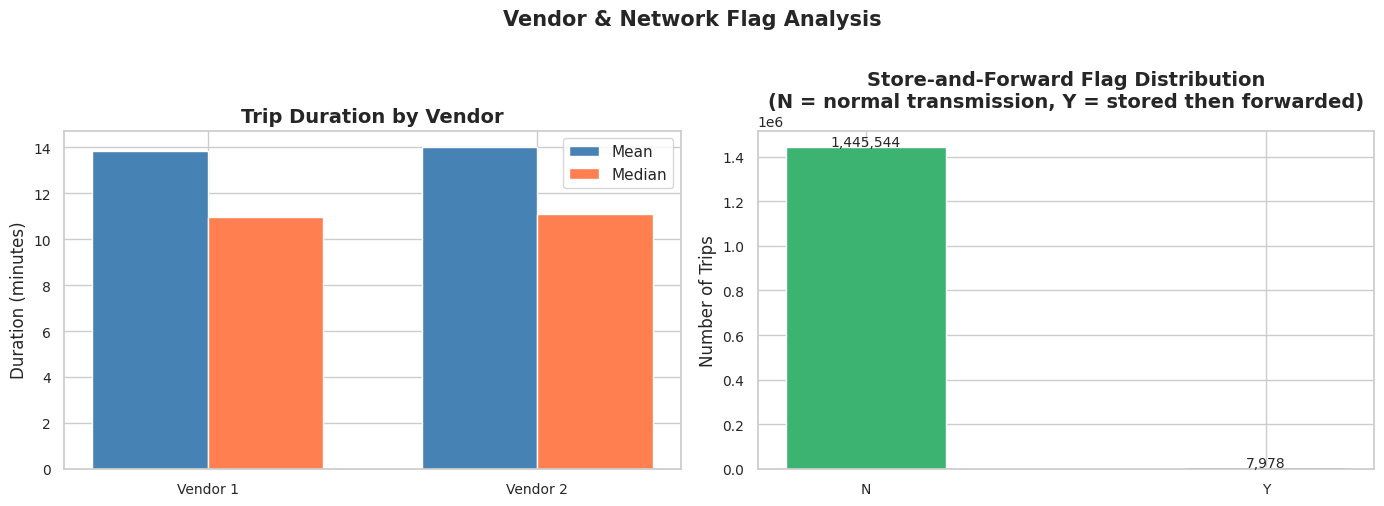

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Vendor vs duration ───────────────────────────────────────────────────────
vendor_stats = df.groupby('vendor_id')['trip_duration'].agg(['mean','median'])
vendor_stats /= 60   # convert to minutes

x = range(len(vendor_stats))
w = 0.35
axes[0].bar([i - w/2 for i in x], vendor_stats['mean'],   width=w, label='Mean',   color='steelblue')
axes[0].bar([i + w/2 for i in x], vendor_stats['median'], width=w, label='Median', color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"Vendor {v}" for v in vendor_stats.index])
axes[0].set_ylabel("Duration (minutes)")
axes[0].set_title("Trip Duration by Vendor")
axes[0].legend()

# ── Store and forward flag ───────────────────────────────────────────────────
flag_counts = df['store_and_fwd_flag'].value_counts()
axes[1].bar(flag_counts.index, flag_counts.values,
            color=['mediumseagreen','tomato'], edgecolor='white', width=0.4)
axes[1].set_title("Store-and-Forward Flag Distribution\n"
                   "(N = normal transmission, Y = stored then forwarded)")
axes[1].set_ylabel("Number of Trips")
for i, (label, val) in enumerate(flag_counts.items()):
    axes[1].text(i, val + 500, f"{val:,}", ha='center', fontsize=10)

plt.suptitle("Vendor & Network Flag Analysis", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



### 👥 5.8 — Passenger Count

How many passengers do most taxis carry?
Single-passenger trips dominate NYC taxis.

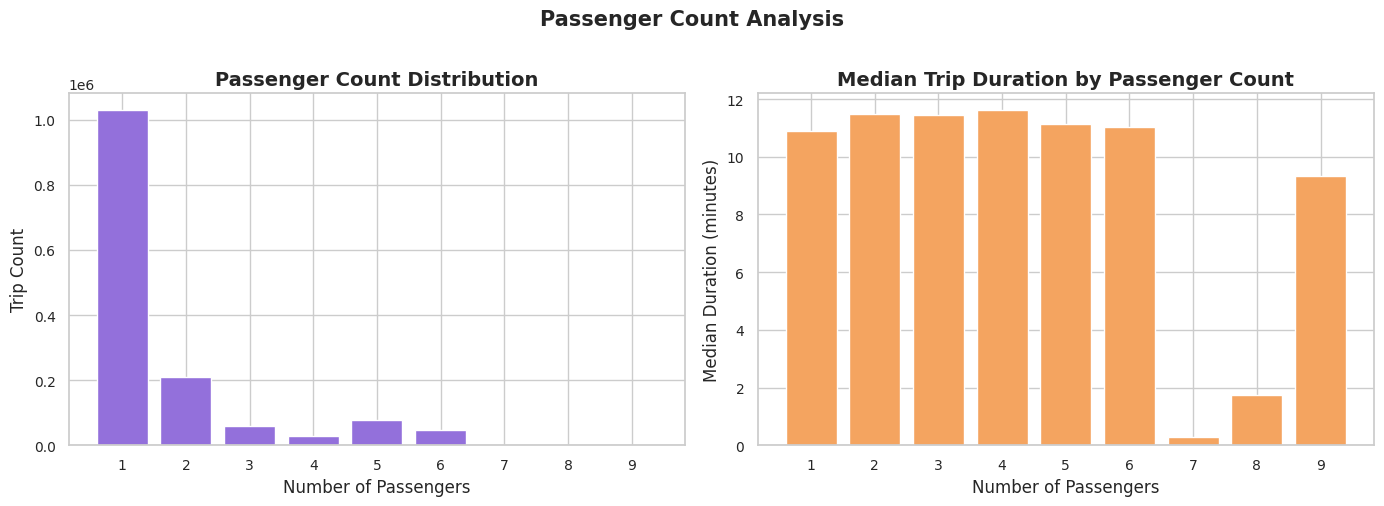

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count distribution
pax_counts = df['passenger_count'].value_counts().sort_index()
axes[0].bar(pax_counts.index, pax_counts.values,
            color='mediumpurple', edgecolor='white')
axes[0].set_title("Passenger Count Distribution")
axes[0].set_xlabel("Number of Passengers")
axes[0].set_ylabel("Trip Count")
axes[0].set_xticks(pax_counts.index)

# Duration by passenger count
pax_dur = df.groupby('passenger_count')['trip_duration'].median() / 60
axes[1].bar(pax_dur.index, pax_dur.values, color='sandybrown', edgecolor='white')
axes[1].set_title("Median Trip Duration by Passenger Count")
axes[1].set_xlabel("Number of Passengers")
axes[1].set_ylabel("Median Duration (minutes)")
axes[1].set_xticks(pax_dur.index)

plt.suptitle("Passenger Count Analysis", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📌 5.9 — Distance vs Duration Scatter

The clearest signal in the dataset:
**longer trips take more time** — but with a significant spread caused by traffic.

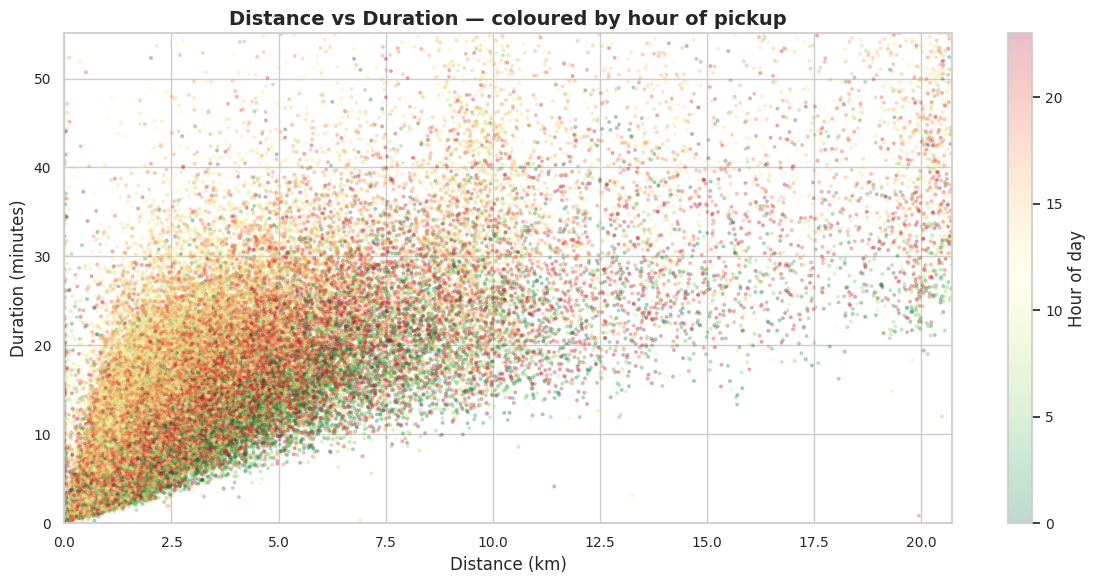

In [46]:
sample = df.sample(n=min(100_000, len(df)), random_state=42)

cap_dist = df['distance_km'].quantile(0.99)
cap_dur  = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    sample['distance_km'], sample['trip_duration'] / 60,
    c=sample['hour'], cmap='RdYlGn_r', alpha=0.25, s=4,
    vmin=0, vmax=23
)
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.set_xlim(0, cap_dist)
ax.set_ylim(0, cap_dur / 60)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Duration (minutes)")
ax.set_title("Distance vs Duration — coloured by hour of pickup")
plt.tight_layout()
plt.show()

### 📦 5.10 — Duration Boxplot by Day

Boxplots reveal the **spread** and **outliers** per day, not just the average.

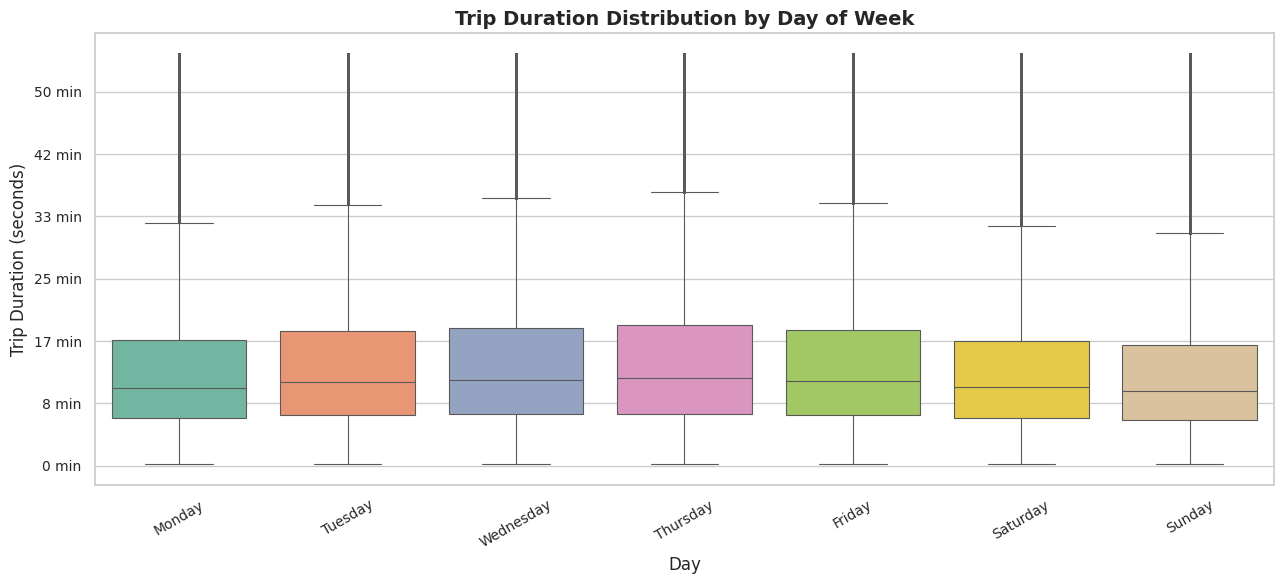

In [47]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
cap_dur   = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df[df['trip_duration'] <= cap_dur],
    x='day_of_week_name', y='trip_duration',
    order=day_order,
    palette='Set2', linewidth=0.8, fliersize=1,
    ax=ax
)
ax.set_title("Trip Duration Distribution by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Trip Duration (seconds)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f} min"))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 🔗 6. Correlation Analysis

The heatmap shows **linear correlations** between numeric features.
`distance_km` has the strongest correlation with trip duration.

> ⚠️ `speed_kmh` will show a very high correlation because it is
> computed *from* the target — this is the leakage in action, not real signal.

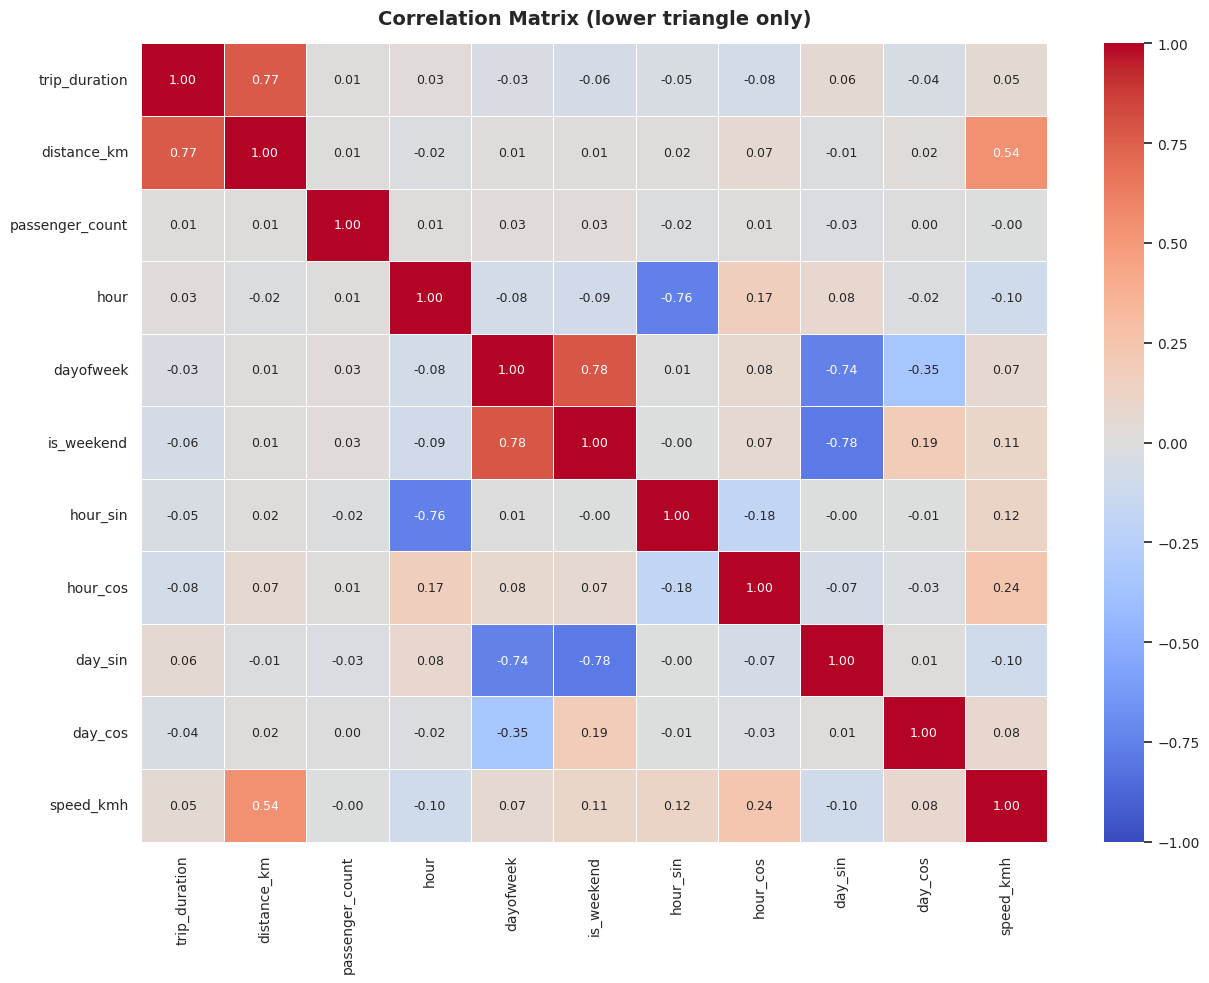

In [48]:
# Columns to include — include speed to visually demonstrate leakage
corr_cols = [
    'trip_duration', 'distance_km', 'passenger_count',
    'hour', 'dayofweek', 'is_weekend',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'speed_kmh',   # ✖️ leaky — included here only for demonstration
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title("Correlation Matrix (lower triangle only)", pad=14)
plt.tight_layout()
plt.show()